# NeuroXVocal — Training & Evaluation
**Server:** Linux | **GPU:** RTX 6000 24 GB | **CUDA:** 12.0

Sections:
- **Part A** — Environment setup
- **Part B** — Data extraction
- **Part C** — Preprocessing
- **Part D** — Training
- **Part E** — Evaluation & VRAM monitor

## Part A — Environment Setup

### A1. Check GPU & CUDA

In [1]:
import torch
import subprocess

print('PyTorch version  :', torch.__version__)
print('CUDA available   :', torch.cuda.is_available())
print('CUDA version     :', torch.version.cuda)

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU              : {props.name}')
    print(f'Total VRAM       : {props.total_memory / 1024**3:.1f} GB')
    print(f'CUDA capability  : {props.major}.{props.minor}')
else:
    print('WARNING: No GPU detected!')

# Show nvidia-smi
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print('\n', result.stdout)

PyTorch version  : 2.5.1+cu121
CUDA available   : True
CUDA version     : 12.1
GPU              : Quadro RTX 6000
Total VRAM       : 23.6 GB
CUDA capability  : 7.5

 Tue Jul 14 21:43:11 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 525.147.05   Driver Version: 525.147.05   CUDA Version: 12.0     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Quadro RTX 6000     On   | 00000000:0B:00.0 Off |                  Off |
| 33%   40C    P8    10W / 260W |    170MiB / 24576MiB |      0%      Default |
|                               |                      |                  N/A |
+-

### A2. Install Dependencies

In [15]:
import subprocess, sys

def run(cmd, label=''):
    print(f'Installing {label}...' if label else f'Running: {cmd[:60]}')
    result = subprocess.run(cmd, shell=True, text=True,
                            stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    last = [l for l in result.stdout.splitlines() if l.strip()][-3:]
    status = 'OK' if result.returncode == 0 else 'ERROR'
    for l in last: print(' ', l)
    print(f'  → {status}\n')

run(f'{sys.executable} -m pip install --upgrade pip -q', 'pip')
run(f'{sys.executable} -m pip install scikit-learn==1.5.2', 'pip')
run(f'{sys.executable} -m pip install protobuf', 'pip')
run(f'{sys.executable} -m pip install torch torchvision torchaudio '
    f'--index-url https://download.pytorch.org/whl/cu121 -q', 'PyTorch (CUDA 12.1)')
run(f'{sys.executable} -m pip install setuptools wheel -q', 'setuptools')
run(f'{sys.executable} -m pip install openai-whisper -q', 'Whisper')
run(f'{sys.executable} -m pip install librosa praat-parselmouth soundfile scipy -q',
    'librosa + parselmouth + soundfile + scipy')
run(f'{sys.executable} -m pip install transformers==4.45.2 sentencepiece -q',
    'transformers 4.45.2 + sentencepiece')
run(f'{sys.executable} -m pip install scikit-learn pandas numpy tqdm joblib matplotlib -q',
    'scikit-learn + pandas + numpy + tqdm + joblib + matplotlib')

print('All dependencies installed.')

# Verify torch sees the GPU
import torch
print(f'PyTorch {torch.__version__} | CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


Installing pip...
  → OK

Installing pip...
  → OK

Installing pip...
  → OK

Installing PyTorch (CUDA 12.1)...
  → OK

Installing setuptools...
  → OK

Installing Whisper...
  → OK

Installing librosa + parselmouth + soundfile + scipy...
  → OK

Installing transformers 4.45.2 + sentencepiece...
  → OK

Installing scikit-learn + pandas + numpy + tqdm + joblib + matplotlib...
  → OK

All dependencies installed.
PyTorch 2.5.1+cu121 | CUDA available: True
GPU: Quadro RTX 6000


### A3. Clone / Update Repository

In [3]:
import os, subprocess

REPO_DIR = os.path.expanduser('/mnt/ssd2/Ali/NeuroXVocal')

# if not os.path.exists(REPO_DIR):
#     subprocess.run(['git', 'clone', 'https://github.com/homiyano/NeuroXVocal.git', REPO_DIR], check=True)
#     print('Cloned to', REPO_DIR)
# else:
#     subprocess.run(['git', '-C', REPO_DIR, 'pull', 'origin', 'main'], check=True)
#     print('Pulled latest changes')

os.listdir(REPO_DIR)

['requirements_cls.txt',
 '.gitignore',
 'NeuroXVocal_Colab_Evaluation.ipynb',
 '.ipynb_checkpoints',
 'NeuroXVocal_Linux_Server.ipynb',
 'README.md',
 'requirements_exp.txt',
 'NeuroXVocal_Colab_Training.ipynb',
 'LICENSE',
 '.git',
 'requirements_app.txt',
 'app',
 'src']

### A4. Configure Paths

In [4]:
import os

# ── CONFIGURE THESE ─────────────────────────────────────────────────
REPO_DIR       = os.path.expanduser('/mnt/ssd2/Ali/NeuroXVocal')
ADRESSO_ROOT   = '/mnt/ssd2/Ali/ADReSSo'
WORK_DIR       = '/mnt/ssd2/Ali/processed'
RESULTS_DIR    = '/mnt/ssd2/Ali/results'
# ────────────────────────────────────────────────────────────────────

AD_WAV_DIR   = os.path.join(ADRESSO_ROOT, 'diagnosis-train/diagnosis/train/audio/ad')
CN_WAV_DIR   = os.path.join(ADRESSO_ROOT, 'diagnosis-train/diagnosis/train/audio/cn')
TEST_WAV_DIR = os.path.join(ADRESSO_ROOT, 'diagnosis-test/diagnosis/test-dist/audio')

AD_WORK = os.path.join(WORK_DIR, 'ad')
CN_WORK = os.path.join(WORK_DIR, 'cn')

os.makedirs(AD_WORK,     exist_ok=True)
os.makedirs(CN_WORK,     exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Verify dataset paths
for label, path in [('AD train', AD_WAV_DIR), ('CN train', CN_WAV_DIR), ('Test', TEST_WAV_DIR)]:
    exists = os.path.isdir(path)
    wavs   = len([f for f in os.listdir(path) if f.endswith('.wav')]) if exists else 0
    print(f'{label:<10}: {"OK" if exists else "NOT FOUND"}  ({wavs} .wav files)  {path}')


AD train  : OK  (87 .wav files)  /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad
CN train  : OK  (79 .wav files)  /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/cn
Test      : OK  (71 .wav files)  /mnt/ssd2/Ali/ADReSSo/diagnosis-test/diagnosis/test-dist/audio


## Part B — Data Extraction

### B1. Transcribe Audio (Whisper)

In [5]:
import whisper, time
from pathlib import Path

def transcribe_dir(wav_dir, out_dir, model):
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    wavs  = sorted(Path(wav_dir).glob('*.wav'))
    print(f'  Found {len(wavs)} files')
    times = []
    for wav in wavs:
        txt_file = Path(out_dir) / (wav.stem + '.txt')
        if txt_file.exists():
            continue
        t0      = time.perf_counter()
        result  = model.transcribe(str(wav), fp16=True)
        elapsed = time.perf_counter() - t0
        times.append(elapsed)
        txt_file.write_text(result['text'], encoding='utf-8')
        print(f'  {wav.name:<35}  {elapsed:.2f}s')
    if times:
        total = sum(times)
        print(f'  ── Total: {total:.1f}s  |  Avg: {total/len(times):.2f}s  |  Files: {len(times)}')
    else:
        print('  All files already transcribed — skipped.')

whisper_model = whisper.load_model('base')

print('Transcribing AD...')
t = time.perf_counter()
transcribe_dir(AD_WAV_DIR, AD_WORK, whisper_model)
print(f'AD done: {time.perf_counter()-t:.1f}s\n')

print('Transcribing CN...')
t = time.perf_counter()
transcribe_dir(CN_WAV_DIR, CN_WORK, whisper_model)
print(f'CN done: {time.perf_counter()-t:.1f}s')

Transcribing AD...
  Found 87 files
  All files already transcribed — skipped.
AD done: 0.0s

Transcribing CN...
  Found 79 files
  All files already transcribed — skipped.
CN done: 0.0s


### B2. Extract Audio Features (librosa + parselmouth)

In [6]:
import time, sys

AD_FEATURES_RAW = os.path.join(AD_WORK, 'audio_features_ad.csv')
CN_FEATURES_RAW = os.path.join(CN_WORK, 'audio_features_cn.csv')
EXTRACT_FEAT    = os.path.join(REPO_DIR, 'src/data_extraction/extract_audio_features.py')

print('Extracting AD audio features...')
t0 = time.perf_counter()
!{sys.executable} {EXTRACT_FEAT} {AD_WAV_DIR} --output_csv {AD_FEATURES_RAW}
print(f'AD features time: {time.perf_counter()-t0:.1f}s\n')

print('Extracting CN audio features...')
t0 = time.perf_counter()
!{sys.executable} {EXTRACT_FEAT} {CN_WAV_DIR} --output_csv {CN_FEATURES_RAW}
print(f'CN features time: {time.perf_counter()-t0:.1f}s')

Extracting AD audio features...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad/adrso089.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad/adrso244.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad/adrso046.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad/adrso122.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad/adrso253.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad/adrso093.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad/adrso141.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad/adrso126.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad/adrso237.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad/adrso197.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/aud

Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/cn/adrso003.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/cn/adrso172.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/cn/adrso153.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/cn/adrso298.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/cn/adrso312.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/cn/adrso315.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/cn/adrso160.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/cn/adrso316.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/cn/adrso156.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/cn/adrso296.wav...
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/cn/adrso178.wav...
Processing

### B3. Extract Audio Embeddings (Wav2Vec2)

In [7]:
import time, sys

AD_EMB_RAW   = os.path.join(AD_WORK, 'audio_embeddings_ad.csv')
CN_EMB_RAW   = os.path.join(CN_WORK, 'audio_embeddings_cn.csv')
EXTRACT_EMB  = os.path.join(REPO_DIR, 'src/data_extraction/extract_audio_embeddings.py')

print('Extracting AD audio embeddings (Wav2Vec2)...')
t0 = time.perf_counter()
!{sys.executable} {EXTRACT_EMB} {AD_WAV_DIR} --output_csv {AD_EMB_RAW}
print(f'AD embeddings time: {time.perf_counter()-t0:.1f}s\n')

print('Extracting CN audio embeddings (Wav2Vec2)...')
t0 = time.perf_counter()
!{sys.executable} {EXTRACT_EMB} {CN_WAV_DIR} --output_csv {CN_EMB_RAW}
print(f'CN embeddings time: {time.perf_counter()-t0:.1f}s')

Extracting AD audio embeddings (Wav2Vec2)...
Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad:   1%Converted stereo to mono for /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad/adrso244.wav
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad:   2%Converted stereo to mono for /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad/adrso046.wav
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad:  10%Converted stereo to mono for /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad/adrso197.wav
Processing /mnt/ssd2/Ali/ADReSSo/diagnosis-train/diagnosis/train/audio/ad:  15%Converted stereo to mono for /mnt/ssd2/Ali/ADRe

## Part C — Preprocessing

### C1. Preprocess Transcriptions

In [8]:
import sys

AD_TEXT_PROC = os.path.join(WORK_DIR, 'ad_text_processed')
CN_TEXT_PROC = os.path.join(WORK_DIR, 'cn_text_processed')
PREPROC_TEXT = os.path.join(REPO_DIR, 'src/data_processing/preprocess_texts.py')

!{sys.executable} {PREPROC_TEXT} {AD_WORK} {AD_TEXT_PROC}
!{sys.executable} {PREPROC_TEXT} {CN_WORK} {CN_TEXT_PROC}
print('Text preprocessing done.')

Processed adrso059.txt
Processed adrso093.txt
Processed adrso036.txt
Processed adrso072.txt
Processed adrso249.txt
Processed adrso237.txt
Processed adrso090.txt
Processed adrso075.txt
Processed adrso211.txt
Processed adrso033.txt
Processed adrso035.txt
Processed adrso128.txt
Processed adrso027.txt
Processed adrso245.txt
Processed adrso063.txt
Processed adrso112.txt
Processed adrso224.txt
Processed adrso070.txt
Processed adrso192.txt
Processed adrso234.txt
Processed adrso215.txt
Processed adrso110.txt
Processed adrso223.txt
Processed adrso198.txt
Processed adrso236.txt
Processed adrso049.txt
Processed adrso144.txt
Processed adrso233.txt
Processed adrso056.txt
Processed adrso122.txt
Processed adrso126.txt
Processed adrso253.txt
Processed adrso123.txt
Processed adrso228.txt
Processed adrso248.txt
Processed adrso138.txt
Processed adrso028.txt
Processed adrso053.txt
Processed adrso054.txt
Processed adrso077.txt
Processed adrso098.txt
Processed adrso190.txt
Processed adrso246.txt
Processed a

### C2. Preprocess Audio Features

In [9]:
import shutil, sys

SCALER_FEAT      = os.path.join(REPO_DIR, 'src/inference/scaler_params_audio_features.pkl')
PREPROC_FEAT     = os.path.join(REPO_DIR, 'src/data_processing/preprocess_audio_features.py')
AD_FEAT_PROC_DIR = os.path.join(WORK_DIR, 'ad_features_processed')
CN_FEAT_PROC_DIR = os.path.join(WORK_DIR, 'cn_features_processed')
os.makedirs(AD_FEAT_PROC_DIR, exist_ok=True)
os.makedirs(CN_FEAT_PROC_DIR, exist_ok=True)

!{sys.executable} {PREPROC_FEAT} --input_path {AD_FEATURES_RAW} --output_path {AD_FEAT_PROC_DIR} --scaler_path {SCALER_FEAT}
!{sys.executable} {PREPROC_FEAT} --input_path {CN_FEATURES_RAW} --output_path {CN_FEAT_PROC_DIR} --scaler_path {SCALER_FEAT}

AD_FEAT_FINAL = os.path.join(AD_WORK, 'audio_features_ad_processed.csv')
CN_FEAT_FINAL = os.path.join(CN_WORK, 'audio_features_cn_processed.csv')
shutil.copy(os.path.join(AD_FEAT_PROC_DIR, 'audio_features_ad.csv'), AD_FEAT_FINAL)
shutil.copy(os.path.join(CN_FEAT_PROC_DIR, 'audio_features_cn.csv'), CN_FEAT_FINAL)
print('Audio features preprocessed.')

Processed file saved at: /mnt/ssd2/Ali/processed/ad_features_processed/audio_features_ad.csv
Processed file saved at: /mnt/ssd2/Ali/processed/cn_features_processed/audio_features_cn.csv
Audio features preprocessed.


### C3. Preprocess Audio Embeddings

In [10]:
import pandas as pd, numpy as np, joblib

SCALER_EMB = os.path.join(REPO_DIR, 'src/inference/scaler_params_audio_emb.pkl')

def preprocess_embeddings(input_csv, output_csv, scaler_path):
    df          = pd.read_csv(input_csv)
    patient_ids = df['patient_id'].values
    features    = df.drop(columns=['patient_id'])
    features    = features.apply(lambda x: x.fillna(x.mean()) if x.isnull().any() else x)
    scaler      = joblib.load(scaler_path)
    scaled      = scaler.transform(features)
    df_out      = pd.DataFrame(scaled, columns=features.columns)
    df_out.insert(0, 'patient_id', patient_ids)
    df_out.to_csv(output_csv, index=False)
    print(f'Saved {output_csv}')

AD_EMB_FINAL = os.path.join(AD_WORK, 'audio_embeddings_ad_processed.csv')
CN_EMB_FINAL = os.path.join(CN_WORK, 'audio_embeddings_cn_processed.csv')

preprocess_embeddings(AD_EMB_RAW, AD_EMB_FINAL, SCALER_EMB)
preprocess_embeddings(CN_EMB_RAW, CN_EMB_FINAL, SCALER_EMB)

Saved /mnt/ssd2/Ali/processed/ad/audio_embeddings_ad_processed.csv
Saved /mnt/ssd2/Ali/processed/cn/audio_embeddings_cn_processed.csv


### C4. Verify All Files Ready

In [11]:
from pathlib import Path
import pandas as pd

checks = [
    ('AD features',   AD_FEAT_FINAL),
    ('CN features',   CN_FEAT_FINAL),
    ('AD embeddings', AD_EMB_FINAL),
    ('CN embeddings', CN_EMB_FINAL),
]
for name, path in checks:
    df = pd.read_csv(path)
    print(f'{name:<16}: {df.shape[0]} patients  {df.shape[1]-1} features')

ad_feat_ids = set(pd.read_csv(AD_FEAT_FINAL)['patient_id'].astype(str))
cn_feat_ids = set(pd.read_csv(CN_FEAT_FINAL)['patient_id'].astype(str))
ad_txt_ids  = {p.stem for p in Path(AD_TEXT_PROC).glob('*.txt')}
cn_txt_ids  = {p.stem for p in Path(CN_TEXT_PROC).glob('*.txt')}

ad_miss = ad_feat_ids - ad_txt_ids
cn_miss = cn_feat_ids - cn_txt_ids
if ad_miss: print(f'WARNING: {len(ad_miss)} AD patients missing transcripts:', ad_miss)
if cn_miss: print(f'WARNING: {len(cn_miss)} CN patients missing transcripts:', cn_miss)
if not ad_miss and not cn_miss:
    print('\nAll patients have transcripts. Ready to train!')

AD features     : 87 patients  47 features
CN features     : 79 patients  47 features
AD embeddings   : 87 patients  768 features
CN embeddings   : 79 patients  768 features

All patients have transcripts. Ready to train!


## Part D — Training

### D1. Write Config & Start Training

In [16]:
config = f'''import os

AD_TEXT_DIR        = r"{AD_TEXT_PROC}"
CN_TEXT_DIR        = r"{CN_TEXT_PROC}"
AD_CSV             = r"{AD_FEAT_FINAL}"
CN_CSV             = r"{CN_FEAT_FINAL}"
AD_EMBEDDING_CSV   = r"{AD_EMB_FINAL}"
CN_EMBEDDING_CSV   = r"{CN_EMB_FINAL}"

TEXT_EMBEDDING_MODEL   = 'microsoft/deberta-v3-base'
NUM_MFCC_FEATURES      = 47
NUM_EMBEDDING_FEATURES = 768
AUDIO_CHANNELS         = 1
CUDA                   = True

BATCH_SIZE              = 8
EPOCHS                  = 200
LEARNING_RATE           = 1e-5
WEIGHT_DECAY            = 1e-4
NUM_FOLDS               = 5
SAVE_BEST_MODEL         = True
EARLY_STOPPING_PATIENCE = 10

SAVE_MODEL_PATH = r"{RESULTS_DIR}/model"
LOG_PATH        = r"{RESULTS_DIR}/training.log"
'''

config_path = os.path.join(REPO_DIR, 'src/train/config.py')
with open(config_path, 'w') as f:
    f.write(config)
print('Config written.')
print(config)

Config written.
import os

AD_TEXT_DIR        = r"/mnt/ssd2/Ali/processed/ad_text_processed"
CN_TEXT_DIR        = r"/mnt/ssd2/Ali/processed/cn_text_processed"
AD_CSV             = r"/mnt/ssd2/Ali/processed/ad/audio_features_ad_processed.csv"
CN_CSV             = r"/mnt/ssd2/Ali/processed/cn/audio_features_cn_processed.csv"
AD_EMBEDDING_CSV   = r"/mnt/ssd2/Ali/processed/ad/audio_embeddings_ad_processed.csv"
CN_EMBEDDING_CSV   = r"/mnt/ssd2/Ali/processed/cn/audio_embeddings_cn_processed.csv"

TEXT_EMBEDDING_MODEL   = 'microsoft/deberta-v3-base'
NUM_MFCC_FEATURES      = 47
NUM_EMBEDDING_FEATURES = 768
AUDIO_CHANNELS         = 1
CUDA                   = True

BATCH_SIZE              = 8
EPOCHS                  = 200
LEARNING_RATE           = 1e-5
WEIGHT_DECAY            = 1e-4
NUM_FOLDS               = 5
SAVE_BEST_MODEL         = True
EARLY_STOPPING_PATIENCE = 10

SAVE_MODEL_PATH = r"/mnt/ssd2/Ali/results/model"
LOG_PATH        = r"/mnt/ssd2/Ali/results/training.log"



In [17]:
import sys, time

MAIN_PY = os.path.join(REPO_DIR, 'src/train/main.py')

print('Starting training...')
print(f'Results will be saved to: {RESULTS_DIR}')
print('─' * 60)

t0 = time.perf_counter()
!cd {os.path.join(REPO_DIR, 'src/train')} && {sys.executable} main.py
total = time.perf_counter() - t0

print('─' * 60)
print(f'Total training time: {total/3600:.2f} hours  ({total/60:.1f} min)')

Starting training...
Results will be saved to: /mnt/ssd2/Ali/results
────────────────────────────────────────────────────────────
Random seed set to 42
Starting k-fold cross-validation training script...
/mnt/ssd2/Ali/miniconda3/envs/neuroxvocal/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:558: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
/mnt/ssd2/Ali/miniconda3/envs/neuroxvocal/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:558: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast 

Fold 1, Epoch 8/200 - Validation: 100%|██████████| 5/5 [00:00<00:00,  6.68it/s]
Fold 1, Epoch 8, Train Loss: 0.5677, Val Loss: 0.5100
Train Classification Report:
              precision    recall  f1-score   support

     Control     0.7286    0.7727    0.7500        66
  ProbableAD     0.7581    0.7121    0.7344        66

    accuracy                         0.7424       132
   macro avg     0.7433    0.7424    0.7422       132
weighted avg     0.7433    0.7424    0.7422       132

Validation Classification Report:
              precision    recall  f1-score   support

     Control     0.7059    0.9231    0.8000        13
  ProbableAD     0.9412    0.7619    0.8421        21

    accuracy                         0.8235        34
   macro avg     0.8235    0.8425    0.8211        34
weighted avg     0.8512    0.8235    0.8260        34

Fold 1, Epoch 9/200 - Validation: 100%|██████████| 5/5 [00:00<00:00,  6.64it/s]
Fold 1, Epoch 9, Train Loss: 0.4459, Val Loss: 0.4070
Train Classific

Fold 1, Epoch 17/200 - Validation: 100%|█████████| 5/5 [00:00<00:00,  6.70it/s]
Fold 1, Epoch 17, Train Loss: 0.0874, Val Loss: 1.6129
Train Classification Report:
              precision    recall  f1-score   support

     Control     0.9429    1.0000    0.9706        66
  ProbableAD     1.0000    0.9394    0.9688        66

    accuracy                         0.9697       132
   macro avg     0.9714    0.9697    0.9697       132
weighted avg     0.9714    0.9697    0.9697       132

Validation Classification Report:
              precision    recall  f1-score   support

     Control     0.8182    0.6923    0.7500        13
  ProbableAD     0.8261    0.9048    0.8636        21

    accuracy                         0.8235        34
   macro avg     0.8221    0.7985    0.8068        34
weighted avg     0.8231    0.8235    0.8202        34

Fold 1, Epoch 18/200 - Validation: 100%|█████████| 5/5 [00:00<00:00,  6.64it/s]
Fold 1, Epoch 18, Train Loss: 0.0391, Val Loss: 1.4519
Train Classif

Fold 2, Epoch 7/200 - Validation: 100%|██████████| 5/5 [00:00<00:00,  6.93it/s]
Fold 2, Epoch 7, Train Loss: 0.1388, Val Loss: 0.0073
Train Classification Report:
              precision    recall  f1-score   support

     Control     0.9538    0.9841    0.9688        63
  ProbableAD     0.9853    0.9571    0.9710        70

    accuracy                         0.9699       133
   macro avg     0.9696    0.9706    0.9699       133
weighted avg     0.9704    0.9699    0.9699       133

Validation Classification Report:
              precision    recall  f1-score   support

     Control     1.0000    1.0000    1.0000        16
  ProbableAD     1.0000    1.0000    1.0000        17

    accuracy                         1.0000        33
   macro avg     1.0000    1.0000    1.0000        33
weighted avg     1.0000    1.0000    1.0000        33

Fold 2, Epoch 8/200 - Validation: 100%|██████████| 5/5 [00:00<00:00,  6.85it/s]
Fold 2, Epoch 8, Train Loss: 0.1330, Val Loss: 0.0060
Train Classific

Fold 2, Epoch 16/200 - Validation: 100%|█████████| 5/5 [00:00<00:00,  6.86it/s]
Fold 2, Epoch 16, Train Loss: 0.1288, Val Loss: 0.0027
Train Classification Report:
              precision    recall  f1-score   support

     Control     0.9683    0.9683    0.9683        63
  ProbableAD     0.9714    0.9714    0.9714        70

    accuracy                         0.9699       133
   macro avg     0.9698    0.9698    0.9698       133
weighted avg     0.9699    0.9699    0.9699       133

Validation Classification Report:
              precision    recall  f1-score   support

     Control     1.0000    1.0000    1.0000        16
  ProbableAD     1.0000    1.0000    1.0000        17

    accuracy                         1.0000        33
   macro avg     1.0000    1.0000    1.0000        33
weighted avg     1.0000    1.0000    1.0000        33

Fold 2, Epoch 17/200 - Validation: 100%|█████████| 5/5 [00:00<00:00,  6.95it/s]
Fold 2, Epoch 17, Train Loss: 0.1910, Val Loss: 0.0032
Train Classif

...

Fold 4, Epoch 50/200 - Validation: 100%|█████████| 5/5 [00:00<00:00,  6.97it/s]
Fold 4, Epoch 50, Train Loss: 0.0006, Val Loss: 0.0001
Train Classification Report:
              precision    recall  f1-score   support

     Control     1.0000    1.0000    1.0000        64
  ProbableAD     1.0000    1.0000    1.0000        69

    accuracy                         1.0000       133
   macro avg     1.0000    1.0000    1.0000       133
weighted avg     1.0000    1.0000    1.0000       133

Validation Classification Report:
              precision    recall  f1-score   support

     Control     1.0000    1.0000    1.0000        15
  ProbableAD     1.0000    1.0000    1.0000        18

    accuracy                         1.0000        33
   macro avg     1.0000    1.0000    1.0000        33
weighted avg     1.0000    1.0000    1.0000        33

Fold 4, Epoch 51/200 - Validation: 100%|█████████| 5/5 [00:00<00:00,  6.93it/s]
Fold 4, Epoch 51, Train Loss: 0.0007, Val Loss: 0.0001
Train Classif

Fold 4, Epoch 59/200 - Validation: 100%|█████████| 5/5 [00:00<00:00,  6.97it/s]
Fold 4, Epoch 59, Train Loss: 0.0005, Val Loss: 0.0001
Train Classification Report:
              precision    recall  f1-score   support

     Control     1.0000    1.0000    1.0000        64
  ProbableAD     1.0000    1.0000    1.0000        69

    accuracy                         1.0000       133
   macro avg     1.0000    1.0000    1.0000       133
weighted avg     1.0000    1.0000    1.0000       133

Validation Classification Report:
              precision    recall  f1-score   support

     Control     1.0000    1.0000    1.0000        15
  ProbableAD     1.0000    1.0000    1.0000        18

    accuracy                         1.0000        33
   macro avg     1.0000    1.0000    1.0000        33
weighted avg     1.0000    1.0000    1.0000        33

Fold 4, Epoch 60/200 - Validation: 100%|█████████| 5/5 [00:00<00:00,  6.98it/s]
Fold 4, Epoch 60, Train Loss: 0.1173, Val Loss: 0.6584
Train Classif

Fold 5, Epoch 2/200 - Validation: 100%|██████████| 5/5 [00:00<00:00,  6.95it/s]
Fold 5, Epoch 2, Train Loss: 0.6984, Val Loss: 0.7075
Train Classification Report:
              precision    recall  f1-score   support

     Control     0.5405    0.3333    0.4124        60
  ProbableAD     0.5833    0.7671    0.6627        73

    accuracy                         0.5714       133
   macro avg     0.5619    0.5502    0.5375       133
weighted avg     0.5640    0.5714    0.5498       133

Validation Classification Report:
              precision    recall  f1-score   support

     Control     0.7143    0.2632    0.3846        19
  ProbableAD     0.4615    0.8571    0.6000        14

    accuracy                         0.5152        33
   macro avg     0.5879    0.5602    0.4923        33
weighted avg     0.6071    0.5152    0.4760        33

Fold 5, Epoch 3/200 - Validation: 100%|██████████| 5/5 [00:00<00:00,  6.91it/s]
Fold 5, Epoch 3, Train Loss: 0.6873, Val Loss: 0.6855
Train Classific

Fold 5, Epoch 11/200 - Validation: 100%|█████████| 5/5 [00:00<00:00,  6.91it/s]
Fold 5, Epoch 11, Train Loss: 0.5167, Val Loss: 0.3789
Train Classification Report:
              precision    recall  f1-score   support

     Control     0.7857    0.9167    0.8462        60
  ProbableAD     0.9206    0.7945    0.8529        73

    accuracy                         0.8496       133
   macro avg     0.8532    0.8556    0.8495       133
weighted avg     0.8598    0.8496    0.8499       133

Validation Classification Report:
              precision    recall  f1-score   support

     Control     0.8182    0.9474    0.8780        19
  ProbableAD     0.9091    0.7143    0.8000        14

    accuracy                         0.8485        33
   macro avg     0.8636    0.8308    0.8390        33
weighted avg     0.8567    0.8485    0.8449        33

Fold 5, Epoch 12/200 - Validation: 100%|█████████| 5/5 [00:00<00:00,  6.93it/s]
Fold 5, Epoch 12, Train Loss: 0.4083, Val Loss: 0.3144
Train Classif

Fold 5, Epoch 20/200 - Validation: 100%|█████████| 5/5 [00:00<00:00,  6.93it/s]
Fold 5, Epoch 20, Train Loss: 0.5807, Val Loss: 0.5751
Train Classification Report:
              precision    recall  f1-score   support

     Control     0.7333    0.5500    0.6286        60
  ProbableAD     0.6932    0.8356    0.7578        73

    accuracy                         0.7068       133
   macro avg     0.7133    0.6928    0.6932       133
weighted avg     0.7113    0.7068    0.6995       133

Validation Classification Report:
              precision    recall  f1-score   support

     Control     0.7647    0.6842    0.7222        19
  ProbableAD     0.6250    0.7143    0.6667        14

    accuracy                         0.6970        33
   macro avg     0.6949    0.6992    0.6944        33
weighted avg     0.7054    0.6970    0.6987        33

Fold 5, Epoch 21/200 - Validation: 100%|█████████| 5/5 [00:00<00:00,  6.94it/s]
Fold 5, Epoch 21, Train Loss: 0.5635, Val Loss: 0.5713
Train Classif

### D2. Training & Validation Loss Plots

Parsed 5 folds
  Fold 1: 19 epochs | best val loss = 0.3506 at epoch 10
  Fold 2: 32 epochs | best val loss = 0.0013 at epoch 23
  Fold 3: 69 epochs | best val loss = 0.0001 at epoch 42
  Fold 4: 66 epochs | best val loss = 0.0001 at epoch 49
  Fold 5: 22 epochs | best val loss = 0.2092 at epoch 13


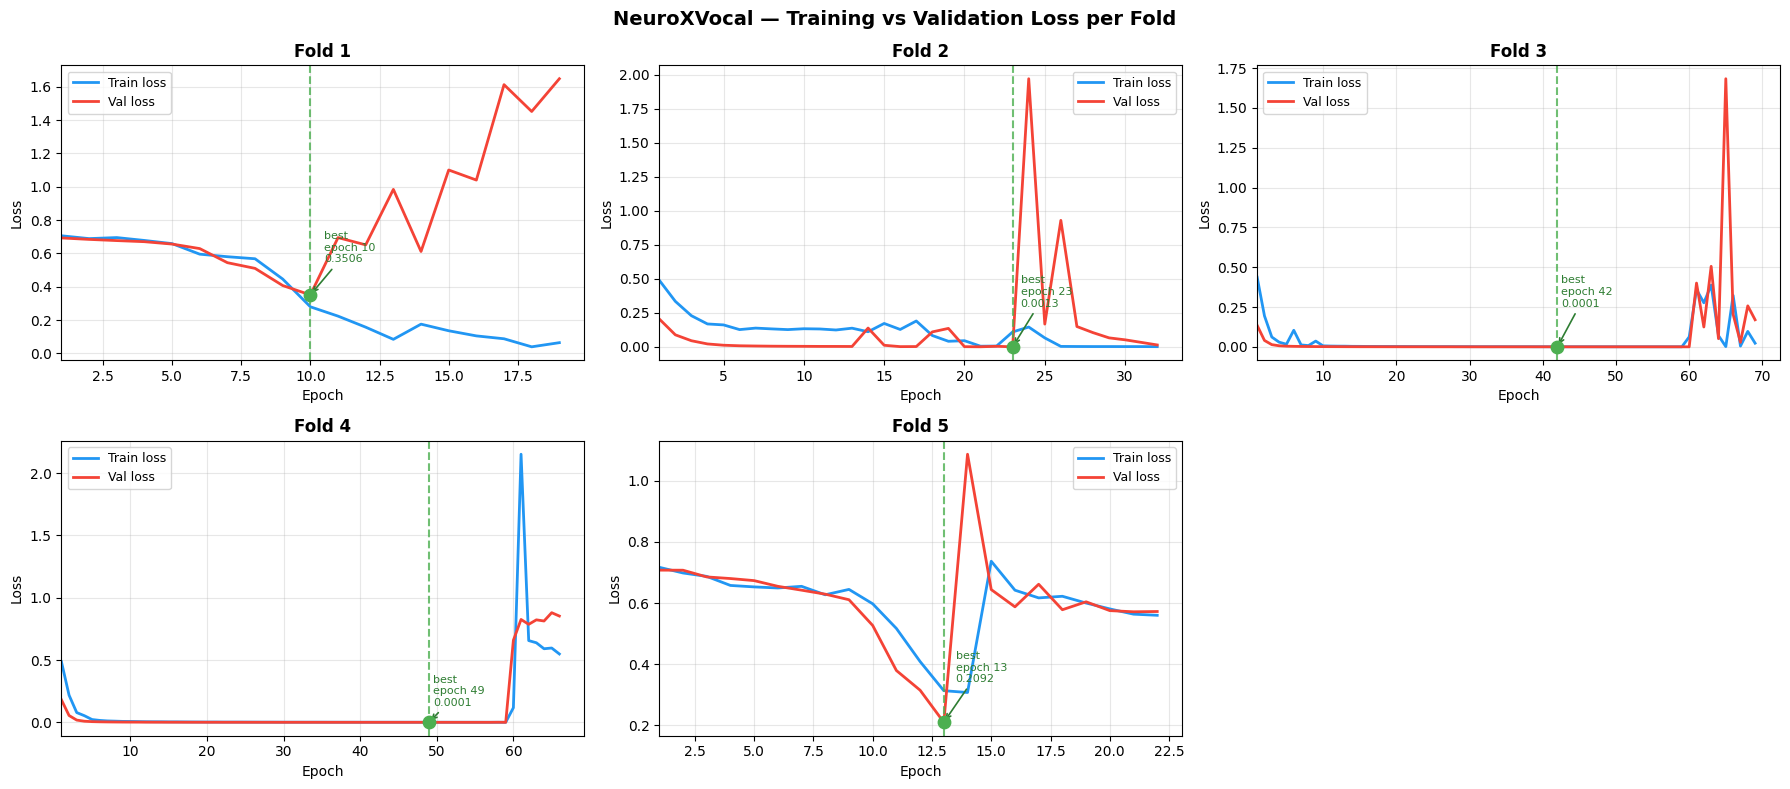

Saved: /mnt/ssd2/Ali/results/loss_curves.png


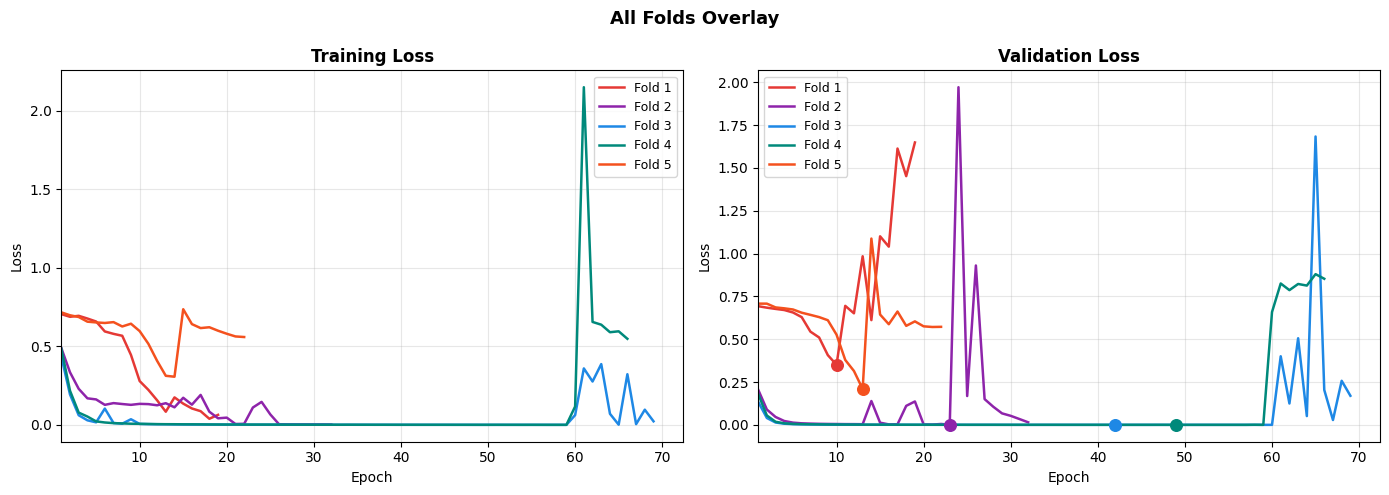

Saved: /mnt/ssd2/Ali/results/loss_overlay.png


In [18]:
import re, os
import matplotlib.pyplot as plt

LOG_PATH = os.path.join(RESULTS_DIR, 'training.log')
pattern  = re.compile(r'Fold (\d+), Epoch (\d+), Train Loss: ([\d.]+), Val Loss: ([\d.]+)')

folds = {}
with open(LOG_PATH) as f:
    for line in f:
        m = pattern.search(line)
        if m:
            fold, epoch = int(m.group(1)), int(m.group(2))
            if fold not in folds:
                folds[fold] = {'epochs': [], 'train': [], 'val': []}
            folds[fold]['epochs'].append(epoch)
            folds[fold]['train'].append(float(m.group(3)))
            folds[fold]['val'].append(float(m.group(4)))

num_folds = len(folds)
print(f'Parsed {num_folds} folds')
for fold, data in sorted(folds.items()):
    best_epoch = data['epochs'][data['val'].index(min(data['val']))]
    print(f'  Fold {fold}: {len(data["epochs"])} epochs | best val loss = {min(data["val"]):.4f} at epoch {best_epoch}')

# ── Per-fold subplots ────────────────────────────────────────────────
cols = min(num_folds, 3)
rows = (num_folds + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
fig.suptitle('NeuroXVocal — Training vs Validation Loss per Fold', fontsize=14, fontweight='bold')
axes_flat = axes.flatten() if num_folds > 1 else [axes]

for idx, (fold, data) in enumerate(sorted(folds.items())):
    ax         = axes_flat[idx]
    best_idx   = data['val'].index(min(data['val']))
    best_epoch = data['epochs'][best_idx]
    best_val   = data['val'][best_idx]

    ax.plot(data['epochs'], data['train'], color='#2196F3', linewidth=2, label='Train loss')
    ax.plot(data['epochs'], data['val'],   color='#F44336', linewidth=2, label='Val loss')
    ax.axvline(x=best_epoch, color='#4CAF50', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.scatter([best_epoch], [best_val], color='#4CAF50', s=80, zorder=5)
    ax.annotate(f'best\nepoch {best_epoch}\n{best_val:.4f}',
                xy=(best_epoch, best_val),
                xytext=(best_epoch+0.5, best_val+(max(data['val'])-min(data['val']))*0.15),
                fontsize=8, color='#2E7D32',
                arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=1.2))
    ax.set_title(f'Fold {fold}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=1)

for idx in range(num_folds, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'loss_curves.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {plot_path}')

# ── All-folds overlay ────────────────────────────────────────────────
FOLD_COLORS = ['#E53935','#8E24AA','#1E88E5','#00897B','#F4511E']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('All Folds Overlay', fontsize=13, fontweight='bold')

for idx, (fold, data) in enumerate(sorted(folds.items())):
    color    = FOLD_COLORS[idx % len(FOLD_COLORS)]
    best_idx = data['val'].index(min(data['val']))
    ax1.plot(data['epochs'], data['train'], color=color, linewidth=1.8, label=f'Fold {fold}')
    ax2.plot(data['epochs'], data['val'],   color=color, linewidth=1.8, label=f'Fold {fold}')
    ax2.scatter([data['epochs'][best_idx]], [data['val'][best_idx]], color=color, s=70, zorder=5)

for ax, title in [(ax1,'Training Loss'), (ax2,'Validation Loss')]:
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(left=1)

plt.tight_layout()
overlay_path = os.path.join(RESULTS_DIR, 'loss_overlay.png')
plt.savefig(overlay_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {overlay_path}')

### D3. Select Best Fold

In [19]:
import glob

model_files = sorted(glob.glob(os.path.join(RESULTS_DIR, '*.pth')))
print('Saved checkpoints:')
for m in model_files:
    print(f'  {os.path.basename(m)}  ({os.path.getsize(m)/1e6:.1f} MB)')

# Pick best fold (lowest val loss)
best_fold = min(folds, key=lambda f: min(folds[f]['val']))
best_loss = min(folds[best_fold]['val'])
best_ep   = folds[best_fold]['epochs'][folds[best_fold]['val'].index(best_loss)]

print(f'\nBest fold: Fold {best_fold}  |  val loss = {best_loss:.4f}  |  epoch = {best_ep}')

best_src  = os.path.join(RESULTS_DIR, f'model_fold{best_fold}_best.pth')
best_dst  = os.path.join(RESULTS_DIR, 'best.pth')
import shutil
shutil.copy(best_src, best_dst)
print(f'Copied {os.path.basename(best_src)} → best.pth')

Saved checkpoints:
  model_fold1_best.pth  (783.2 MB)
  model_fold2_best.pth  (783.2 MB)
  model_fold3_best.pth  (783.2 MB)
  model_fold4_best.pth  (783.2 MB)
  model_fold5_best.pth  (783.2 MB)

Best fold: Fold 3  |  val loss = 0.0001  |  epoch = 42
Copied model_fold3_best.pth → best.pth


## Part E — Evaluation & VRAM Monitor

### E1. VRAM Monitor Class

In [20]:
import time, torch

class VRAMMonitor:
    def __init__(self, device):
        self.device       = device
        self.dtype        = device.type
        self._global_peak = 0.0
        self.load_records = []

    def current_mb(self):
        return torch.cuda.memory_allocated(self.device) / 1024**2 if self.dtype == 'cuda' else 0.0

    def peak_mb(self):
        return torch.cuda.max_memory_allocated(self.device) / 1024**2 if self.dtype == 'cuda' else 0.0

    def reset_peak(self):
        if self.dtype == 'cuda': torch.cuda.reset_peak_memory_stats(self.device)

    def sync(self):
        if self.dtype == 'cuda': torch.cuda.synchronize(self.device)

    def measure(self, label):
        return _Stage(self, label)

    def record_load(self, name, fn):
        self.sync()
        before = self.current_mb()
        obj    = fn()
        self.sync()
        after  = self.current_mb()
        delta  = after - before
        self.load_records.append({'model': name, 'before_mb': round(before,1),
                                   'after_mb': round(after,1), 'delta_mb': round(delta,1)})
        print(f'  Loaded {name:<26}  before={before:6.1f} MB  after={after:6.1f} MB  delta=+{delta:.1f} MB')
        return obj

    def update_global_peak(self, v):
        if v > self._global_peak: self._global_peak = v

    def global_peak_mb(self):
        return self._global_peak


class _Stage:
    def __init__(self, mon, label):
        self.mon   = mon
        self.label = label
        self.vram_before = self.vram_after = self.peak = self.elapsed = 0.0

    def __enter__(self):
        self.mon.sync()
        self.mon.reset_peak()
        self.vram_before = self.mon.current_mb()
        self._t0         = time.perf_counter()
        return self

    def __exit__(self, *_):
        self.mon.sync()
        self.elapsed    = time.perf_counter() - self._t0
        self.vram_after = self.mon.current_mb()
        self.peak       = self.mon.peak_mb()
        self.mon.update_global_peak(self.peak)

print('VRAMMonitor ready.')

VRAMMonitor ready.


### E2. Load All Models (with VRAM tracking)

In [21]:
import sys, re, tempfile, shutil, subprocess, joblib, warnings
import whisper, soundfile as sf
import pandas as pd, numpy as np
from pathlib import Path
from math import gcd
from scipy.signal import resample_poly
from transformers import AutoTokenizer, Wav2Vec2Model, Wav2Vec2Processor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

sys.path.insert(0, os.path.join(REPO_DIR, 'src/train'))
from models import NeuroXVocal

SCALER_FEAT = os.path.join(REPO_DIR, 'src/inference/scaler_params_audio_features.pkl')
SCALER_EMB  = os.path.join(REPO_DIR, 'src/inference/scaler_params_audio_emb.pkl')
DROP_COLS   = ['jitter_local','shimmer_local','formant_1_mean','formant_1_std',
               'formant_2_mean','formant_2_std','formant_3_mean','formant_3_std','class']
TEXT_MODEL  = 'microsoft/deberta-v3-base'
MODEL_PATH  = os.path.join(RESULTS_DIR, 'best.pth')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mon    = VRAMMonitor(device)
print(f'Device: {device}\n')

wmodel    = mon.record_load('Whisper base',
                lambda: whisper.load_model('base'))
tokenizer = mon.record_load('DeBERTa tokenizer',
                lambda: AutoTokenizer.from_pretrained(TEXT_MODEL))
processor = mon.record_load('Wav2Vec2 processor',
                lambda: Wav2Vec2Processor.from_pretrained('facebook/wav2vec2-base-960h'))
emodel    = mon.record_load('Wav2Vec2 model',
                lambda: Wav2Vec2Model.from_pretrained('facebook/wav2vec2-base-960h').to(device).eval())

def _load_clf():
    clf = NeuroXVocal(num_audio_features=47, num_embedding_features=768, text_embedding_model=TEXT_MODEL)
    sd  = torch.load(MODEL_PATH, map_location=device)
    if 'module.' in list(sd.keys())[0]:
        from collections import OrderedDict
        sd = OrderedDict((k.replace('module.',''), v) for k, v in sd.items())
    clf.load_state_dict(sd)
    return clf.to(device).eval()

clf = mon.record_load('NeuroXVocal (DeBERTa)', _load_clf)

print('\n── Model Load Summary ──────────────────────────────────────────')
print(f'  {"Model":<28}  {"Before":>9}  {"After":>9}  {"Delta":>9}')
print('  ' + '-'*58)
for r in mon.load_records:
    print(f'  {r["model"]:<28}  {r["before_mb"]:>8.1f}M  {r["after_mb"]:>8.1f}M  +{r["delta_mb"]:>7.1f}M')

/mnt/ssd2/Ali/miniconda3/envs/neuroxvocal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda

  Loaded Whisper base                before= 279.4 MB  after= 558.8 MB  delta=+279.4 MB


/mnt/ssd2/Ali/miniconda3/envs/neuroxvocal/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:558: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


  Loaded DeBERTa tokenizer           before= 558.8 MB  after= 558.8 MB  delta=+0.0 MB
  Loaded Wav2Vec2 processor          before= 558.8 MB  after= 558.8 MB  delta=+0.0 MB


Some weights of Wav2Vec2Model were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Loaded Wav2Vec2 model              before= 558.8 MB  after= 921.0 MB  delta=+362.2 MB


/mnt/ssd2/Ali/miniconda3/envs/neuroxvocal/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
/tmp/ipykernel_792704/3924582396.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add

  Loaded NeuroXVocal (DeBERTa)       before= 921.0 MB  after=1669.2 MB  delta=+748.2 MB

── Model Load Summary ──────────────────────────────────────────
  Model                            Before      After      Delta
  ----------------------------------------------------------
  Whisper base                     279.4M     558.8M  +  279.4M
  DeBERTa tokenizer                558.8M     558.8M  +    0.0M
  Wav2Vec2 processor               558.8M     558.8M  +    0.0M
  Wav2Vec2 model                   558.8M     921.0M  +  362.2M
  NeuroXVocal (DeBERTa)            921.0M    1669.2M  +  748.2M


### E3. Run Evaluation with VRAM & Timing Monitor
3 pipelines tracked per patient: Whisper → Wav2Vec2 → NeuroXVocal classifier

In [22]:
from tqdm import tqdm

def transcribe(wav_path):
    r = wmodel.transcribe(str(wav_path), fp16=torch.cuda.is_available())
    t = r['text'].lower()
    return re.sub(r'[^a-zA-Z0-9\s.,!?]', '', ' '.join(t.split()))

def get_audio_features(wav_path):
    script = os.path.join(REPO_DIR, 'src/data_extraction/extract_audio_features.py')
    tmp    = Path(tempfile.mkdtemp())
    csv    = tmp / 'f.csv'
    subprocess.run([sys.executable, script, str(wav_path.parent),
                    '--output_csv', str(csv)], capture_output=True)
    df  = pd.read_csv(csv)
    shutil.rmtree(tmp)
    row = df[df['patient_id'] == wav_path.stem]
    pid = row['patient_id'].values
    row = row.drop(columns=['patient_id'] + DROP_COLS, errors='ignore')
    row = row.apply(lambda x: x.fillna(x.mean()) if x.isnull().any() else x)
    scaled = joblib.load(SCALER_FEAT).transform(row)
    out = pd.DataFrame(scaled, columns=row.columns)
    out.insert(0, 'patient_id', pid)
    return out

def get_embeddings(wav_path):
    speech, sr = sf.read(str(wav_path), always_2d=True)
    speech     = speech.mean(axis=1).astype(np.float32)
    if sr != 16000:
        g = gcd(sr, 16000)
        speech = resample_poly(speech, 16000//g, sr//g).astype(np.float32)
    inp = processor(speech, sampling_rate=16000, return_tensors='pt', padding=True)
    inp = {k: v.to(device) for k, v in inp.items()}
    with torch.no_grad():
        emb = emodel(**inp).last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return joblib.load(SCALER_EMB).transform(emb.reshape(1,-1)).flatten()

def predict(text, feat_row, emb):
    tok  = tokenizer(text, padding='max_length', truncation=True, max_length=512, return_tensors='pt')
    tok  = {k: v.to(device) for k, v in tok.items()}
    af   = torch.tensor(feat_row.drop(columns=['patient_id']).iloc[0].values.astype(float),
                        dtype=torch.float32).unsqueeze(0).to(device)
    embt = torch.tensor(emb, dtype=torch.float32).unsqueeze(0).to(device)
    with torch.no_grad():
        conf = torch.sigmoid(clf(tok, af, embt)).item()
    return (1 if conf > 0.5 else 0), conf

# ── Main loop ────────────────────────────────────────────────────────
wav_files       = sorted(Path(TEST_WAV_DIR).glob('*.wav'))
results         = []
monitor_records = []

for wav in tqdm(wav_files, desc='Patients'):
    pid = wav.stem
    try:
        with mon.measure('1. Whisper transcription') as s1:
            text = transcribe(wav)
        monitor_records.append({'patient': pid, 'pipeline': '1. Whisper transcription',
                                'vram_before_mb': round(s1.vram_before,1), 'vram_peak_mb': round(s1.peak,1),
                                'vram_after_mb': round(s1.vram_after,1), 'time_sec': round(s1.elapsed,3)})

        t0        = time.perf_counter()
        feat_proc = get_audio_features(wav)
        monitor_records.append({'patient': pid, 'pipeline': '2a. AudioFeat (subprocess)',
                                'vram_before_mb': None, 'vram_peak_mb': None,
                                'vram_after_mb': None, 'time_sec': round(time.perf_counter()-t0,3)})

        with mon.measure('2b. Wav2Vec2 embedding') as s2:
            emb_proc = get_embeddings(wav)
        monitor_records.append({'patient': pid, 'pipeline': '2b. Wav2Vec2 embedding',
                                'vram_before_mb': round(s2.vram_before,1), 'vram_peak_mb': round(s2.peak,1),
                                'vram_after_mb': round(s2.vram_after,1), 'time_sec': round(s2.elapsed,3)})

        with mon.measure('3. NeuroXVocal classify') as s3:
            pred, conf = predict(text, feat_proc, emb_proc)
        monitor_records.append({'patient': pid, 'pipeline': '3. NeuroXVocal classify',
                                'vram_before_mb': round(s3.vram_before,1), 'vram_peak_mb': round(s3.peak,1),
                                'vram_after_mb': round(s3.vram_after,1), 'time_sec': round(s3.elapsed,3)})

        results.append({'patient_id': pid, 'prediction': pred,
                        'label': 'AD' if pred==1 else 'CN',
                        'confidence': round(conf,4), 'transcription': text[:100]})
    except Exception as e:
        print(f'ERROR {pid}: {e}')
        results.append({'patient_id': pid, 'prediction': None,
                        'label': 'ERROR', 'confidence': None, 'transcription': str(e)})

OUTPUT_CSV  = os.path.join(RESULTS_DIR, 'predictions.csv')
MONITOR_CSV = os.path.join(RESULTS_DIR, 'vram_monitor.csv')

df_results = pd.DataFrame(results)
df_monitor = pd.DataFrame(monitor_records)
df_results.to_csv(OUTPUT_CSV,  index=False)
df_monitor.to_csv(MONITOR_CSV, index=False)
print(f'Predictions saved → {OUTPUT_CSV}')
print(f'VRAM log saved    → {MONITOR_CSV}')
df_results[['patient_id','label','confidence']]

Patients: 100%|█████████████████████████████| 71/71 [3:55:19<00:00, 198.87s/it]

Predictions saved → /mnt/ssd2/Ali/results/predictions.csv
VRAM log saved    → /mnt/ssd2/Ali/results/vram_monitor.csv


,patient_id,label,confidence
0,adrsdt1,AD,0.9999
1,adrsdt10,AD,0.9999
2,adrsdt11,CN,0.0001
3,adrsdt12,CN,0.0001
4,adrsdt13,CN,0.0001
...,...,...,...
66,adrsdt7,AD,0.9999
67,adrsdt70,AD,0.9999
68,adrsdt71,AD,0.9999
69,adrsdt8,AD,0.9999


### E4. Prediction Summary & VRAM Report

In [23]:
valid = df_results.dropna(subset=['prediction'])
print(f'Total processed : {len(valid)} / {len(df_results)}')
print(f'Predicted AD    : {(valid["prediction"]==1).sum()}')
print(f'Predicted CN    : {(valid["prediction"]==0).sum()}')
print(f'\nConfidence stats:')
print(valid['confidence'].describe().round(4))

print('\n')

# Model load table
df_load = pd.DataFrame(mon.load_records)
print('MODEL LOAD — VRAM COST')
print('=' * 62)
print(df_load.to_string(index=False))

# Per-pipeline summary
tracked = df_monitor[df_monitor['vram_peak_mb'].notna()].copy()
summary = tracked.groupby('pipeline').agg(
    peak_max  = ('vram_peak_mb', 'max'),
    peak_min  = ('vram_peak_mb', 'min'),
    peak_mean = ('vram_peak_mb', 'mean'),
    time_mean = ('time_sec',     'mean'),
).round(2)

print('\nVRAM & TIMING SUMMARY')
print('=' * 72)
print(f'{"Pipeline":<28}  {"Peak max":>9}  {"Peak min":>9}  {"Peak avg":>9}  {"Avg time":>9}')
print('-' * 72)
for pipe, row in summary.iterrows():
    print(f'{pipe:<28}  {row.peak_max:>8.1f}M  {row.peak_min:>8.1f}M  {row.peak_mean:>8.1f}M  {row.time_mean:>8.2f}s')
print('=' * 72)
print(f'Global peak VRAM : {mon.global_peak_mb():.1f} MB')
print(f'Global min  VRAM : {tracked["vram_peak_mb"].min():.1f} MB')

Total processed : 71 / 71
Predicted AD    : 41
Predicted CN    : 30

Confidence stats:
count    71.0000
mean      0.5841
std       0.4925
min       0.0001
25%       0.0001
50%       0.9999
75%       0.9999
max       0.9999
Name: confidence, dtype: float64


MODEL LOAD — VRAM COST
                model  before_mb  after_mb  delta_mb
         Whisper base      279.4     558.8     279.4
    DeBERTa tokenizer      558.8     558.8       0.0
   Wav2Vec2 processor      558.8     558.8       0.0
       Wav2Vec2 model      558.8     921.0     362.2
NeuroXVocal (DeBERTa)      921.0    1669.2     748.2

VRAM & TIMING SUMMARY
Pipeline                       Peak max   Peak min   Peak avg   Avg time
------------------------------------------------------------------------
1. Whisper transcription        1806.4M    1755.6M    1786.0M      1.84s
2b. Wav2Vec2 embedding          3563.4M    1958.7M    2591.9M      0.34s
3. NeuroXVocal classify         1781.4M    1781.4M    1781.4M      0.03s
Global peak V

### E5. Accuracy vs Ground Truth (optional)

In [24]:
# Set path to ground truth CSV if available: columns (patient_id, label) where 1=AD 0=CN
LABELS_CSV = None

if LABELS_CSV is not None:
    gt     = pd.read_csv(LABELS_CSV)
    merged = df_results.merge(gt, on='patient_id', suffixes=('_pred','_true'))
    merged = merged.dropna(subset=['prediction'])
    y_true = merged['label_true'].astype(int).values
    y_pred = merged['prediction'].astype(int).values
    acc    = accuracy_score(y_true, y_pred)
    print(f'Test Accuracy: {acc*100:.2f}%  ({int(acc*len(y_true))}/{len(y_true)})\n')
    print(classification_report(y_true, y_pred, target_names=['CN','AD']))
    print('Confusion Matrix:')
    print(pd.DataFrame(confusion_matrix(y_true, y_pred),
                       index=['True CN','True AD'], columns=['Pred CN','Pred AD']))
else:
    print('LABELS_CSV not set. Provide ground truth CSV to compute accuracy.')

LABELS_CSV not set. Provide ground truth CSV to compute accuracy.
